# Deep Learning & Recurrent Neural Networks (RNN) in pytorch : Training language model for generating sequences (One-to-Many)

**Authored by Alexandre Mathias DONNAT, Sr - Télécom Paris**


## Objective:

- We will train a network to learn a language model and then use it to generate new sequences.

- Instead of training the language model on text-documents (as it is the case in most examples) we will train it to learn the language of the music of [Johann_Sebastian_Bach](https://en.wikipedia.org/wiki/Johann_Sebastian_Bach).
For this, we will learn how J. S. Bach's "Cello suite" have been composed.
Here is an example of a "Cello suite" [Link](https://www.youtube.com/watch?v=mGQLXRTl3Z0).

- Rather than analyzing the audio signal, we use a symbolic representation of the "Cello suite" through their [MIDI files](https://en.wikipedia.org/wiki/MIDI#MIDI_files).
  - A MIDI file encodes in a file, the set of musical notes, their duration, and intensity which have to be played by each instrument to "render" a musical piece. The "rendering" is usually operated by a MIDI synthesizer (such as VLC, QuickTime) or a real performer (a musician reading a score).

- We will first train a language model on the whole set of MIDI files of the "Cello suites".
- We will then sample this language model to create a new MIDI file which will be a brand new "Cello suite" composed by the computer.

### Questions:

In the bottom part of this lab, we will have to answer a set of questions. Answers to those only necessitates a couple of sentences.

## Import packages

In [2]:
import os
import pretty_midi
from scipy.io import wavfile
import IPython

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import glob
from argparse import Namespace
import time

student = True

## Parameters of the model

In [3]:
param = Namespace()

param.n_x = 79 # --- input dimension of x<t>, number of musical-pitch considered
param.max_midi_T_x = 1000 # --- maximum considered length of each bach suite
param.model_T_x = 100 # --- considered duration T_x of sequence for training and generation
param.model_n_a = 32 # --- hidden dimension of LSTM

param.dropout_rate = 0.3
param.batch_size = 64
param.n_epoch = 1000

param.model_T_generate = 100 # --- number of time steps to generate

# Get the data

## Collect data to create the language model

We download the 36 MIDI files corresponding to the 36 "Cello suites" composed by J. S. Bach.

In [ ]:
import urllib.request
urllib.request.urlretrieve('https://drive.google.com/uc?export=download&id=1FzNBMlhSYdefQUHpfRykY05CsYkuI2Ez', 'Archive.zip')
import shutil
shutil.unpack_archive('Archive.zip', './', 'zip')

DIR = './'
midi_file_l = glob.glob(DIR + 'cs*.mid')
print(midi_file_l)

['.\\cs1-1pre.mid', '.\\cs1-2all.mid', '.\\cs1-3cou.mid', '.\\cs1-4sar.mid', '.\\cs1-5men.mid', '.\\cs1-6gig.mid', '.\\cs2-1pre.mid', '.\\cs2-2all.mid', '.\\cs2-3cou.mid', '.\\cs2-4sar.mid', '.\\cs2-5men.mid', '.\\cs2-6gig.mid', '.\\cs3-1pre.mid', '.\\cs3-2all.mid', '.\\cs3-3cou.mid', '.\\cs3-4sar.mid', '.\\cs3-5bou.mid', '.\\cs3-6gig.mid', '.\\cs4-1pre.mid', '.\\cs4-2all.mid', '.\\cs4-3cou.mid', '.\\cs4-4sar.mid', '.\\cs4-5bou.mid', '.\\cs4-6gig.mid', '.\\cs5-1pre.mid', '.\\cs5-2all.mid', '.\\cs5-3cou.mid', '.\\cs5-4sar.mid', '.\\cs5-5gav.mid', '.\\cs5-6gig.mid', '.\\cs6-1pre.mid', '.\\cs6-2all.mid', '.\\cs6-3cou.mid', '.\\cs6-4sar.mid', '.\\cs6-5gav.mid', '.\\cs6-6gig.mid']


## Read and convert all MIDI files

We illustrate here the content of a MIDI file. Each file contains a list of notes to be played over time. Each note is characterized by
- its `pitch` (in MIDI note number, la3=A4=69)
- its `start` time (when to start playing the note)
- its `stop` time (when to stop playing the note)
- its `duration` (which is computed as stop-start)

In [5]:
# --- Read a single MIDI file
midi_data = pretty_midi.PrettyMIDI(midi_file_l[0])
# --- Display the note pitch, start, end and duration
for note in midi_data.instruments[0].notes[:10]:
    print('pitch: %d, start: %f, end: %f, duration: %f' % (note.pitch, note.start, note.end, note.end-note.start))

pitch: 43, start: 0.000000, end: 0.187500, duration: 0.187500
pitch: 50, start: 0.187500, end: 0.375000, duration: 0.187500
pitch: 59, start: 0.375000, end: 0.562500, duration: 0.187500
pitch: 57, start: 0.562500, end: 0.750000, duration: 0.187500
pitch: 59, start: 0.750000, end: 0.937500, duration: 0.187500
pitch: 50, start: 0.937500, end: 1.125000, duration: 0.187500
pitch: 59, start: 1.125000, end: 1.312500, duration: 0.187500
pitch: 50, start: 1.312500, end: 1.500000, duration: 0.187500
pitch: 43, start: 1.500000, end: 1.687500, duration: 0.187500
pitch: 50, start: 1.687500, end: 1.875000, duration: 0.187500


For each MIDI file,
- we read it
- we only retain the `pitch` information (we name it `note`) .
- we convert this list of notes (`note_l`)  to a one-hot-encoding matrix `X_ohe` of dimensions `(midi_T_x, param.n_x)` where `param.n_x` is the number of possible musical notes.

Remark: the length of the sequences `midi_T_x` can vary from one sequence to the other but is truncated to `param.max_midi_T_x`.



In [ ]:
def F_convert_midi_2_list(midi_file_l, n_x, max_midi_T_x):
    """
    read the notes within all midi files
    truncate the length if > max_midi_T_x

    Parameters
    ----------
    midi_file_l:
        list of MIDI files
    n_x:
        dimension of the one-hot-encoding
    max_midi_T_x:
        the maximum number of notes we read in a given midi_file

    Returns
    -------
    X_list:
        a list of np.array X_ohe of size (midi_T_x, n_x) which contains the one-hot-encoding representation of notes over time
    """
    X_list = []

    for midi_file in midi_file_l:
        # --- read the MIDI file
        midi_data = pretty_midi.PrettyMIDI(midi_file)

        # --- extract pitches
        note_l = [note.pitch for note in midi_data.instruments[0].notes]

        # --- truncate if necessary
        midi_T_x = min(len(note_l), max_midi_T_x)

        # --- convert to one-hot-encoding
        if student:
            base_pitch = 43

            X_ohe = np.zeros((midi_T_x, n_x), dtype=np.float32)

            for t in range(midi_T_x):
                pitch = note_l[t]
                idx = pitch - base_pitch

                if 0 <= idx < n_x:
                    X_ohe[t, idx] = 1.0

        # --- add X_ohe to the list X_list
        X_list.append(X_ohe)

    return X_list

In [9]:
X_list = F_convert_midi_2_list(midi_file_l, param.n_x, param.max_midi_T_x)
print(len(X_list))
print(X_list[0].shape)
print(X_list[1].shape)
print(X_list[2].shape)

36
(593, 79)
(914, 79)
(812, 79)


## Display the set of notes over time for a specific track

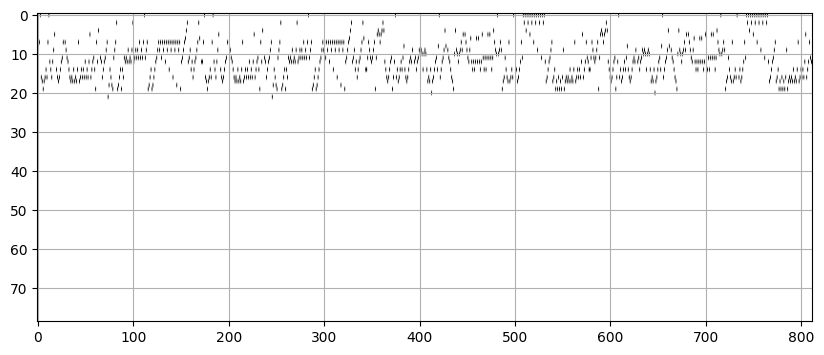

In [14]:
plt.figure(figsize=(10, 4))
plt.imshow(X_list[2].T, aspect='auto')
plt.set_cmap('gray_r')
plt.grid(True)

## Data conversion for the training of language model

We want to train a language model, i.e. a model thats predict a note given past notes: $p(x^{<\tau>} | x^{<1>}, x^{<2>}, ... x^{<\tau-1>})$.

A simple way to do this is to create (for each MIDI sequence and for each possible starting note `t` within this MIDI sequence) two sequences:
- an input sequence $\{x\}$:
  - which contains a sub-sequence of length `param.model_T_x`;  this sub-sequence range from `t` to `t+param.model_T_x-1`
- an output sequence $\{y\}$ :
  - which contains the same sub-sequence but delayed by one time step: ranging from `t+1` to `t+param.model_T_x`

<img src="https://perso.telecom-paristech.fr/gpeeters/doc/Lab_DL_RNN_03.png">



In [17]:
def F_convert_list_2_data(X_list, model_T_x):
    """
    Convert a list of one-hot encoded MIDI sequences into a training dataset
    for a next-step prediction language model.

    For each sequence X_ohe (midi_T_x, n_x), we create pairs (X_seq, Y_seq):
      X_seq = X_ohe[t : t+model_T_x]
      Y_seq = X_ohe[t+1 : t+model_T_x+1]

    Returns
    -------
    X_train: np.array of shape (m, model_T_x, n_x)
    Y_train: np.array of shape (m, model_T_x, n_x)
    """
    X_data = []
    Y_data = []

    for X_ohe in X_list:
        midi_T_x = X_ohe.shape[0]

        # need at least model_T_x + 1 time steps to make (X, Y)
        if midi_T_x <= model_T_x:
            continue

        for t in range(midi_T_x - model_T_x):
            X_seq = X_ohe[t : t + model_T_x]
            Y_seq = X_ohe[t + 1 : t + model_T_x + 1]

            X_data.append(X_seq)
            Y_data.append(Y_seq)

    X_train = np.array(X_data, dtype=np.float32)
    Y_train = np.array(Y_data, dtype=np.float32)

    return X_train, Y_train

X_train.shape: (20901, 100, 79)
Y_train.shape: (20901, 100, 79)


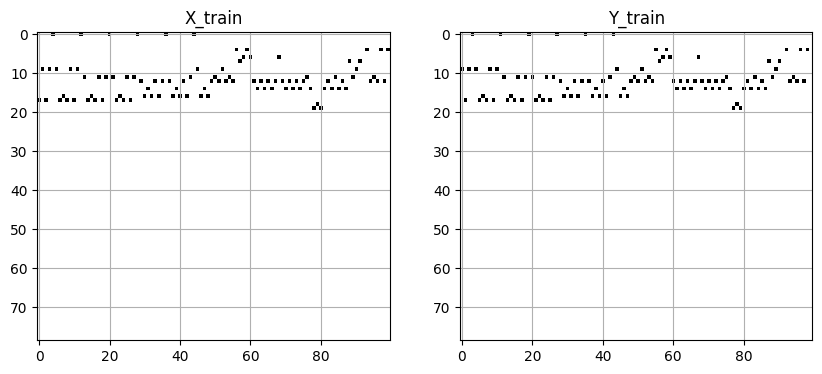

In [18]:
X_train, Y_train = F_convert_list_2_data(X_list, param.model_T_x)
# --- X_train is of shape (m, model_T_x, n_x)
print("X_train.shape:", X_train.shape)
# --- Y_train is of shape (m, model_T_x, n_x)
print("Y_train.shape:", Y_train.shape)


plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.imshow(X_train[20,:,:].T, aspect='auto'); plt.grid(True); plt.title('X_train')
plt.subplot(1,2,2); plt.imshow(Y_train[20,:,:].T, aspect='auto'); plt.grid(True); plt.title('Y_train')
plt.set_cmap('gray_r')

# Training the language model

## Creating the model
To learn the language model we will train an RNN with input `X_train` and output `Y_train`.  
For each example, we give to the network a sequence of notes from `t` to `t+param.model_T_x-1`  and ask the network to predict the following note of each sequence `t+1` to `t+param.model_T_x`.
We already created those in `X_train` and `Y_train`.

The network architecture is the following:
- (1a) a layer of `LSTM` with `param.model_n_a` units
- (1b) a layer of DropOut with rate `param.dropout_rate` (which is the probability to "drop-out" one neuron)

- (2a) a layer of `LSTM` with `param.model_n_a` units
- (2b) a layer of DropOut with rate `param.dropout_rate` (which is the probability to "drop-out" one neuron)

- (3) a layer of `LSTM` with `param.model_n_a` units

- (4a) a `Linear` layer projecting to `model_n_a` neurons with a `tanh` activation
- (4b) a layer of DropOut with rate `param.dropout_rate` (which is the probability to "drop-out" one neuron)

- (5) a `Linear` layer projecting to `n_x` neurons

Note that the last `softmax` activation (which predict the probability of each of the $n_x$ notes as output) is not included in the model but will be included directly in the Loss.

Note that the `.forward` method
- also takes as **input** the previous RNN values $s^{(t-1)}$. The previous RNN value sums up the times $x^{(1)} ... x^{(t-1)}$.
In the case of LSTM, $s^{(t-1)}$ is actually a tuple which represent the LSTM hidden state value $h^{(t-1)}$ and LSTM cell (memory) value $c^{(t-1)}$.
Also when several layers of LSTM exist, each layer will have a specific $s^{(t-1)}$ (such as $s^{(t-1),[1]}$, $s^{(t-1),[2]}$ and $s^{(t-1),[3]}$ for three layers).
- also **outputs** the new value of those $s^{(t),[1]}$, $s^{(t),[2]}$ and $s^{(t),[3]}$.

$h$ and $c$ are merged into tuples named `hidden` and since we have three LSTM cell we will have the corresponding `hidden1`, `hidden2` and `hidden3`.   

In [ ]:
# --- Create the model

if student:
    class BachModel(nn.Module):

        def __init__(self, param):
            super().__init__()

            self.n_x = param.n_x
            self.n_a = param.model_n_a
            self.dropout_rate = param.dropout_rate

            # (1a) LSTM + (1b) Dropout
            self.lstm1 = nn.LSTM(input_size=self.n_x, hidden_size=self.n_a, num_layers=1, batch_first=True)
            self.drop1 = nn.Dropout(self.dropout_rate)

            # (2a) LSTM + (2b) Dropout
            self.lstm2 = nn.LSTM(input_size=self.n_a, hidden_size=self.n_a, num_layers=1, batch_first=True)
            self.drop2 = nn.Dropout(self.dropout_rate)

            # (3) LSTM
            self.lstm3 = nn.LSTM(input_size=self.n_a, hidden_size=self.n_a, num_layers=1, batch_first=True)

            # (4a) Linear -> n_a + tanh, (4b) Dropout
            self.fc1 = nn.Linear(self.n_a, self.n_a)
            self.tanh = nn.Tanh()
            self.drop3 = nn.Dropout(self.dropout_rate)

            # (5) Linear -> n_x (logits)
            self.fc2 = nn.Linear(self.n_a, self.n_x)

        def forward(self, x, hidden1, hidden2, hidden3):
            """
            Parameters
            ----------
                x (batch_size, T_x, n_x)
                hidden1, hidden2, hidden3: tuples (h, c) each of shape (1, batch_size, n_a)

            Returns
            -------
                logits (batch_size, T_x, n_x)
                hidden1, hidden2, hidden3 (updated)
            """
            # layer 1
            out1, hidden1 = self.lstm1(x, hidden1)
            out1 = self.drop1(out1)

            # layer 2
            out2, hidden2 = self.lstm2(out1, hidden2)
            out2 = self.drop2(out2)

            # layer 3
            out3, hidden3 = self.lstm3(out2, hidden3)

            # time-distributed FC: apply on last dim
            z = self.fc1(out3)
            z = self.tanh(z)
            z = self.drop3(z)

            logits = self.fc2(z)

            return logits, hidden1, hidden2, hidden3

        def init_hidden(self, batch_size, model_n_a):
            """
            Initialize hidden state and cell state with zeros
            """
            hidden1 = (torch.zeros(1, batch_size, model_n_a).float().to(device),
                       torch.zeros(1, batch_size, model_n_a).float().to(device))
            hidden2 = (torch.zeros(1, batch_size, model_n_a).float().to(device),
                       torch.zeros(1, batch_size, model_n_a).float().to(device))
            hidden3 = (torch.zeros(1, batch_size, model_n_a).float().to(device),
                       torch.zeros(1, batch_size, model_n_a).float().to(device))
            return hidden1, hidden2, hidden3

# fix seed
import torch
torch.manual_seed(0)

# --- check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Instantiate the model and send it to the GPU if available
model = BachModel(param).to(device)
hidden1, hidden2, hidden3 = model.init_hidden(param.batch_size, param.model_n_a)
print(model)


Using device: cpu
BachModel(
  (lstm1): LSTM(79, 32, batch_first=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(32, 32, batch_first=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (lstm3): LSTM(32, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (tanh): Tanh()
  (drop3): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=79, bias=True)
)


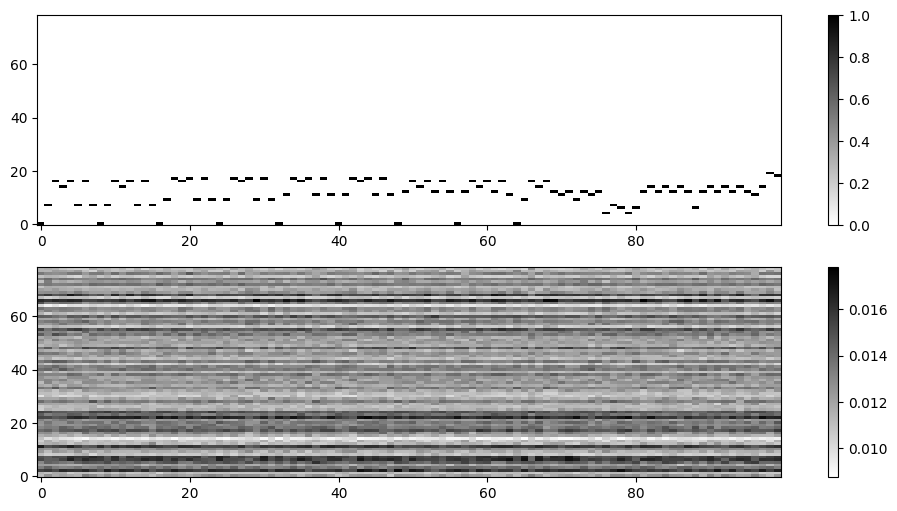

In [25]:
import warnings
warnings.filterwarnings("ignore")

def plot_test(X_train):
    """
    display the obtained probability estimation for a given sequence
    """
    # ----------------------------------------------
    input = torch.tensor(X_train[:1,:,:]).float()
    hidden1, hidden2, hidden3 = model.init_hidden(input.size(0), param.model_n_a)
    output, _, _, _ = model( input.to(device), hidden1, hidden2, hidden3 )
    #print(f'input: {input.size()} hidden1: {hidden1[0].size()} output: {output.size()}')

    plt.figure(figsize=(12,6))
    plt.subplot(211), plt.imshow(input[0,:,:].T.numpy(), aspect='auto', origin='lower', interpolation='none');
    plt.colorbar()
    plt.subplot(212), plt.imshow(F.softmax(output[0,:,:]).detach().cpu().T.numpy(), aspect='auto', origin='lower', interpolation='none')
    plt.colorbar()
    plt.show()

plot_test(X_train);

In [26]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    """
    """

    model.train()
    total_loss = 0
    for X, y in data_loader:
        optimizer.zero_grad()
        # --- X (m, T_x, n_x)
        m = X.size(0)
        hidden1, hidden2, hidden3 = model.init_hidden(m, param.model_n_a)
        hat_y, _, _, _ = model( X, hidden1, hidden2, hidden3 )
        hat_y = hat_y.view(m * param.model_T_x, param.n_x)
        y_bol = torch.argmax(y, dim=2)
        y_bol = y_bol.view(m * param.model_T_x)

        loss = criterion(hat_y, y_bol)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss/len(data_loader)

In [27]:
def train(model, X_train, Y_train, epochs=param.n_epoch, batch_size=param.batch_size):

    """
    train the model

    Parameters
    ----------
    model:
        ...


    Returns
    -------
    """

    # --- Move the model to the device (GPU or CPU)
    model = model.to(device)

    # ---  Convert numpy.arrays to torch.tensor
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).to(device)

    # ---  Create Datasets for train data
    train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

    # --- Create Dataloader for train data
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # ---  Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=0.01)

    # ---  Training loop
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        if epoch%100==0:
            print(f"Epoch {epoch + 1}, Loss: {train_loss }")
            plot_test(X_train)

Epoch 1, Loss: 3.0071992844981157


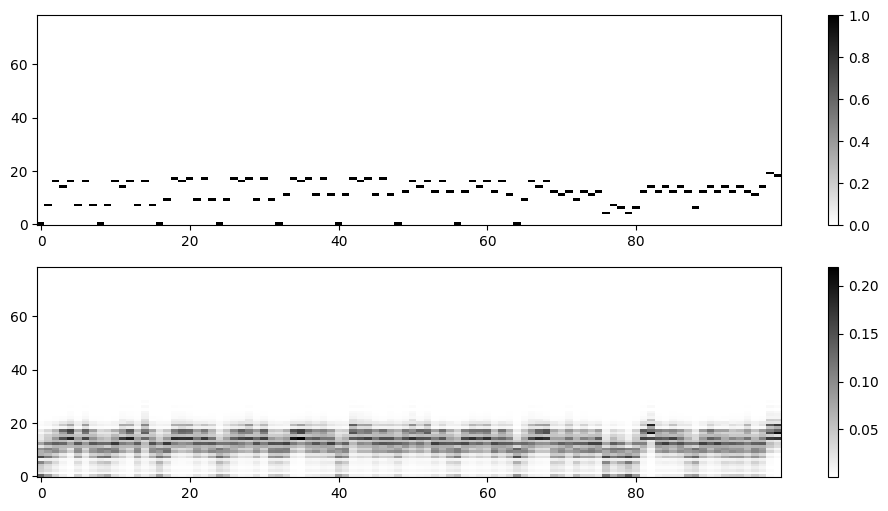

Epoch 101, Loss: 1.560938656512386


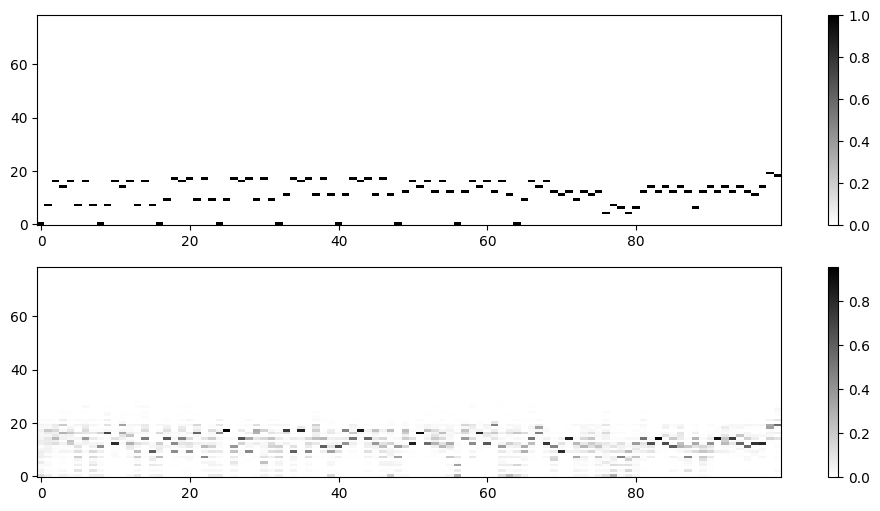

KeyboardInterrupt: 

In [28]:
train(model, X_train, Y_train)

# Generating a new sequence by sampling the language model

To generate a new sequence using the trained language model, we will use an **auto-regressive** method: we generate time-step $t$ based on the previously generated time-steps $0$ to $t-1$.

For the first step
- $\hat{y}^{(1)} = p(x^{(2)} | \color{red}{x^{(1)}} ; \color{blue}{s^{(0)}=[-]})\\x^{(2)} \sim \hat{y}^{(1)}$

For the second step
- $\hat{y}^{(2)} = p(x^{(3)} | \color{red}{x^{(2)}} ; \color{blue}{s^{(1)}=[x^{(1)}]})\\x^{(3)} \sim \hat{y}^{(2)}$

The third step
- $\hat{y}^{(3)} = p(x^{(4)} |\color{red}{ x^{(3)}} ; \color{blue}{s^{(2)}=[x^{(1)} x^{(2)}]})\\x^{(4)} \sim \hat{y}^{(3)}$

For the $t$ step:
- $\hat{y}^{(t)} = p(x^{(t+1)} | \color{red}{{x^{(t)}}} ; \color{blue}{s^{(t-1)}=[x^{(1)} ... x^{(t-1)}]})\\x^{(t+1)} \sim \hat{y}^{(t)}$

In the above "$\sim$" denotes "sampled from the distribution"

At time step $t$, the model gets
- as input (red part): the previous generated time step $x^{(t)} \sim \hat{y}^{(t-1)}$
- as previous RNN value (blue part) $s^{(t-1)}$. The previous RNN value sums up the times $x^{(1)} ... x^{(t-1)}$.
In the case of LSTM, $s^{(t-1)}$ is actually a tuple which represent the LSTM hidden state value $h^{(t-1)}$ and LSTM cell (memory) value $c^{(t-1)}$.
Also when several layers of LSTM exist, each layer will have a specific $s^{(t-1)}$ (such as $s^{(t-1),[1]}$, $s^{(t-1),[2]}$ and $s^{(t-1),[3]}$ for three layers).


### Initialisation (`t=1`)

For the start, we set $x^{(1)}$ to a randomly choosen note among the `param.n_x` possible notes. For this we can
- either sample from an uniform distribution among the notes -> `get_prior_uniform`
- or sample from a prior note distribution (the prior can be obtained by counting the number of occurences of each notes in the training set) -> `get_prior_data_distribution`

To sample from a distribution we can use `np.random.multinomial`.

We then create an input `x` that will be used by our `model`. Our model requires data of shape `(m, T_x, n_x)`. In our case
- `m=1` since we have only one sequence,
- `T_x=1` since we only consider one time at a given time (auto-regressive)
- `n_x` is the number of notes.

We set the input data `x[0,0,:]` to the one-hot-encoding of our random note $x^{(1)}$.

For the start, we do not have previous RNN values, we therefore set $s^{(0)}$ to 0.
This is done using `model.init_hidden`. We denote those `hidden1, hidden2, hidden3`.

We then feed our model with data `x[0,0,:]` and `hidden1, hidden2, hidden3`.

### Loop

At time $t$, our model predict $\hat{y}^{(t)}=p(x^{(t+1)} | \color{red}{{x^{(t)}}} ; \color{blue}{s^{(t-1)}=[x^{(1)} ... x^{(t-1)}]})$.

The inputs of the model are
- the one-hot-encoding of the previously chosen note $x^{(t)} \sim \hat{y}^{(t-1)}$; it is stored in `x[0,0,:]`
- the previous RNN value $s^{(t-1)}$; it is stored in `hidden1, hidden2, hidden3`

The outputs of `model.forward()` are
- the `logits` $\in [-\inf,\inf]$ of shape `(1, 1, n_x)` of each note (remember that the `softmax` is not part of our model; the softmax is included in the Loss, not in the model).
- the new RNN values $s^{(t)}$

To get $\hat{y}^{(t)}$ from the logits at time `t`, we can  
- (a) either convert this logit vector to a probablity using standard softmax -> `get_softmax`
- (b) or convert this logit vector to a probablity using a softmax **with temperature** -> `get_softmax_temperature`.
To apply a temperature $T$ parameter to a discrete probability $\{p_c\}_{c \in \{1,...,K\}}$, we can use
$p'_c = \frac{e^{\log(p_c)/T}}{\sum_{k=1}^K e^{\log(p_k)/T}}$ where $K$ is the number of classes.

To get $x^{(t+1)}$ from the resulting probablity $\hat{y}^{(t)}$ we can then
- (a) either select the largest probability -> `np.argmax`
- (b) or consider the probability as a multinomial distribution and sample from it -> `np.random.multinomial`.

We append the chosen note $x^{(t+1)}$ to the list of chosen notes ->  `note_l.append()`.
We append the used probablity $\hat{y}^{(t)}$ to the list of probablities -> `prediction_l.append()`.

### Stop criteria

We repeat the process until we generate the required amount of notes `param.model_T_generate`.





In [30]:
# --- np: numpy
# --- to: pytorch

def get_prior_uniform(n_x):
    """
    """
    prior_np_v = np.ones(n_x)/n_x
    return prior_np_v

def get_prior_data_distribution(X_train_np, n_x):
    """
    """
    sum_np_v = np.zeros(n_x)
    for X_ohe_np in X_train_np:
        sum_np_v += np.sum(X_ohe_np, axis=0)
    prior_np_v = sum_np_v/np.sum(sum_np_v)
    return prior_np_v

def get_softmax(hat_logit_to):
    """
    """
    proba_np_v = F.softmax( hat_logit_to.double() ).numpy()
    return proba_np_v

def get_softmax_temperature(hat_logit_to, temperature):
    """
    compute a softmax with temperature
    """
    if student:
        # logits (torch) -> numpy proba
        # softmax_T(z) = softmax(z / T)
        z = (hat_logit_to.double() / temperature)
        proba_np_v = F.softmax(z, dim=-1).detach().cpu().numpy()
    return proba_np_v

def choose_max(proba_np_v):
    """
    """
    index_pred = np.argmax(proba_np_v)
    return index_pred

def choose_max_multinormial(proba_np_v):
    """
    """
    index_pred = np.argmax(np.random.multinomial(1, proba_np_v))
    return index_pred

In [ ]:
def F_sample_new_sequence(model):
    """
    sample the trained language model to generate new data
    """
    np.random.seed(0)
    note_l = []
    prediction_l = []

    if student:

        model.eval()

        # --- choose prior for first note
        # prior_np_v = get_prior_uniform(param.n_x)
        prior_np_v = get_prior_data_distribution(X_train, param.n_x)

        # --- sample first note index from the prior
        note0 = np.argmax(np.random.multinomial(1, prior_np_v))
        note_l.append(note0)

        # --- build first input x of shape (1, 1, n_x)
        x = torch.zeros(1, 1, param.n_x, dtype=torch.float32).to(device)
        x[0, 0, note0] = 1.0

        # --- init hidden states
        hidden1, hidden2, hidden3 = model.init_hidden(batch_size=1, model_n_a=param.model_n_a)

        # --- generation loop (we already have 1 note)
        temperature = 1.0  # we can change (e.g. 0.8 or 1.2)

        for t in range(param.model_T_generate - 1):

            with torch.no_grad():
                logits, hidden1, hidden2, hidden3 = model(x, hidden1, hidden2, hidden3)

            # logits: (1, 1, n_x) -> vector (n_x,)
            hat_logit_to = logits[0, 0, :].detach().cpu()

            # --- convert logits -> probabilities
            if temperature == 1.0:
                proba_np_v = get_softmax(hat_logit_to)
            else:
                proba_np_v = get_softmax_temperature(hat_logit_to, temperature)

            # proba_np_v might be shape (n_x,) or (n_x,) wrapped; enforce 1D
            proba_np_v = np.squeeze(proba_np_v)

            # --- choose next note (sample)
            note_next = choose_max_multinormial(proba_np_v)

            # store
            note_l.append(note_next)
            prediction_l.append(proba_np_v)

            # update input x for next step
            x.zero_()
            x[0, 0, note_next] = 1.0

    return note_l, prediction_l

### Display the generated sequence

[np.int64(8), np.int64(10), np.int64(0), np.int64(10), np.int64(13), np.int64(10), np.int64(10), np.int64(8), np.int64(7), np.int64(5), np.int64(7), np.int64(7), np.int64(8), np.int64(0), np.int64(1), np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(5), np.int64(7), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(17), np.int64(17), np.int64(17), np.int64(15), np.int64(0), np.int64(0), np.int64(0), np.int64(7), np.int64(8), np.int64(7), np.int64(8), np.int64(10), np.int64(12), np.int64(10), np.int64(13), np.int64(8), np.int64(7), np.int64(5), np.int64(7), np.int64(6), np.int64(4), np.int64(5), np.int64(4), np.int64(0), np.int64(8), np.int64(3), np.int64(2), np.int64(7), np.int64(0), np.int64(7), np.int64(5), np.int64(0), np.int64(7), np.int64(8), np.int64(7), np.int64(8), np.int64(12), np.int64(10), np.int64(8), np.int64(7), np.int64(5), np.int64(5), np.int64(3), np.int64(0), np.int64(3), np.int64(5), np.int64(7), np.int64(8), np.int64(10), np.i

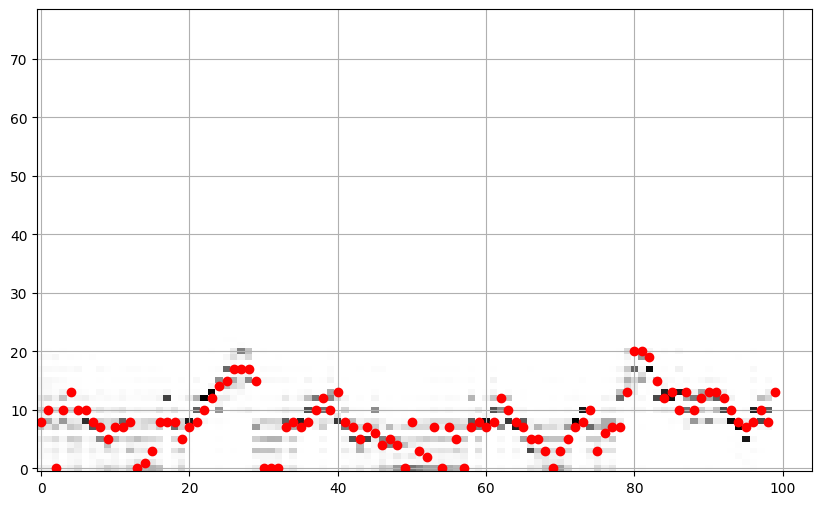

In [32]:
note_l, prediction_l = F_sample_new_sequence(model)

print(note_l)
plt.figure(figsize=(10, 6))
plt.imshow(np.asarray(prediction_l).T, aspect='auto', origin='lower')
plt.plot(note_l, 'ro')
plt.set_cmap('gray_r')
plt.grid(True)

### Create a MIDI file and an audio file which correspond to the generated sequence

Once the new sequence has been generated (```note_l```) we transform it to a new MIDI file and perform (a very cheap) rendering of it in an audio file.

In [ ]:
base_pitch = 43  

new_midi_data = pretty_midi.PrettyMIDI()
cello_program = pretty_midi.instrument_name_to_program("Cello")
cello = pretty_midi.Instrument(program=cello_program)

time = 0.0
step = 0.30

for note_idx in note_1:
    pitch_midi = int(base_pitch + int(note_idx))
    myNote = pretty_midi.Note(
        velocity=100,
        pitch=pitch_midi,
        start=time,
        end=time + step
    )
    cello.notes.append(myNote)
    time += step

new_midi_data.instruments.append(cello)

# Player
audio_data = new_midi_data.synthesize(fs=44100)
IPython.display.Audio(audio_data, rate=44100)

# Evaluation

To evaluate the work, we should rate the code for
- 1) MIDI conversion to one-hot-encoding: `F_convert_midi_2_list` (01)
- 2) Data conversion for the training of language model (02) `F_convert_list_2_data`
- 3) Training the language model (03)
- 4) Generating a new sequence from sampling the language model `F_sample_new_sequence` (04)


1) MIDI → one-hot encoding (F_convert_midi_2_list): 9/10  
The conversion from MIDI pitches to one-hot vectors is correct, including sequence truncation (max_midi_T_x) and safe handling of pitches outside the allowed range. A critical point is maintaining consistency of the chosen base_pitch during both encoding and MIDI reconstruction.

2) List → training dataset (F_convert_list_2_data): 10/10  
The sliding-window mechanism correctly builds (X_seq, Y_seq) pairs using X[t:t+T] and Y[t+1:t+T+1]. The resulting shapes (m, T_x, n_x) are consistent with a next-step language modeling objective. The logic strictly matches standard sequence prediction training.

3) Training the language model (BachModel + training loop): 8/10  
The architecture follows the specification (3 LSTM layers, dropout, tanh MLP projection, final linear layer). CrossEntropyLoss is correctly applied to class indices. Potential improvements include lowering the learning rate (e.g., 1e-3 instead of 1e-2), adding early stopping or a scheduler, and reducing plotting during training to speed up CPU execution.

4) Sequence generation (F_sample_new_sequence): 9/10  
The auto-regressive generation is correctly implemented: prior-based initialization, step-by-step inference (T_x = 1), softmax (with optional temperature), and multinomial sampling. A key detail is converting predicted class indices back to real MIDI pitches (pitch = base_pitch + index) to produce audible output.